## 📝 Instrucciones

**Clasificador de Vinos con KNN**

Entrena un modelo de K-Vecinos más Cercanos (KNN) para predecir la calidad de un vino tinto a partir de sus características químicas. ¿Podría una IA ayudarte a elegir un vino digno de sommelier?

## Descripción de las columnas

**Cada fila representa un vino. Las columnas describen su composición química:**

    -fixed acidity, volatile acidity, citric acid
    -residual sugar, chlorides
    -free sulfur dioxide, total sulfur dioxide
    -density, pH, sulphates, alcohol

La columna objetivo es label:

0 = Baja calidad

1 = Calidad media

2 = Alta calidad

**¡Empecemos! 😎**

### 1. Carga los datos. Carga el CSV con Pandas y explora su estructura.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [10]:
df = pd.read_csv("../data/raw/winequality.csv", sep=";")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


**Sin valores nulos y todas las variables numéricas**

In [20]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.320,1.741,4.600,7.100,7.900,9.200,15.900
volatile acidity,1599.0,0.528,0.179,0.120,0.390,0.520,0.640,1.580
citric acid,1599.0,0.271,0.195,0.000,0.090,0.260,0.420,1.000
residual sugar,1599.0,2.539,1.410,0.900,1.900,2.200,2.600,15.500
chlorides,1599.0,0.087,0.047,0.012,0.070,0.079,0.090,0.611
free sulfur dioxide,1599.0,15.875,10.460,1.000,7.000,14.000,21.000,72.000
total sulfur dioxide,1599.0,46.468,32.895,6.000,22.000,38.000,62.000,289.000
density,1599.0,0.997,0.002,0.990,0.996,0.997,0.998,1.004
pH,1599.0,3.311,0.154,2.740,3.210,3.310,3.400,4.010
sulphates,1599.0,0.658,0.170,0.330,0.550,0.620,0.730,2.000


**En general todas las variables a simple vista siguen distribuciones más o menos normales. No se ven tantos outliers ni std muy altas (con excepción quizás de los sulfur dioxides). El principal problema es el desbalance entre escalas de las variables. Será necesario escalar más adelante**

In [17]:
df["quality"].value_counts()


quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

**La variable objetivo (quality) está muy desbalanceada y con categorías diferentes a las que se piden en el ejercicio así que es necesario agrupar**

In [18]:
def quality_recategorize(quality):
    if quality <=5:
        return 0
    elif quality == 6:
        return 1
    else:
        return 2

In [19]:
df["quality"] = df["quality"].apply(quality_recategorize)
df["quality"].value_counts()

quality
0    744
1    638
2    217
Name: count, dtype: int64

#### EDA Gráfico:

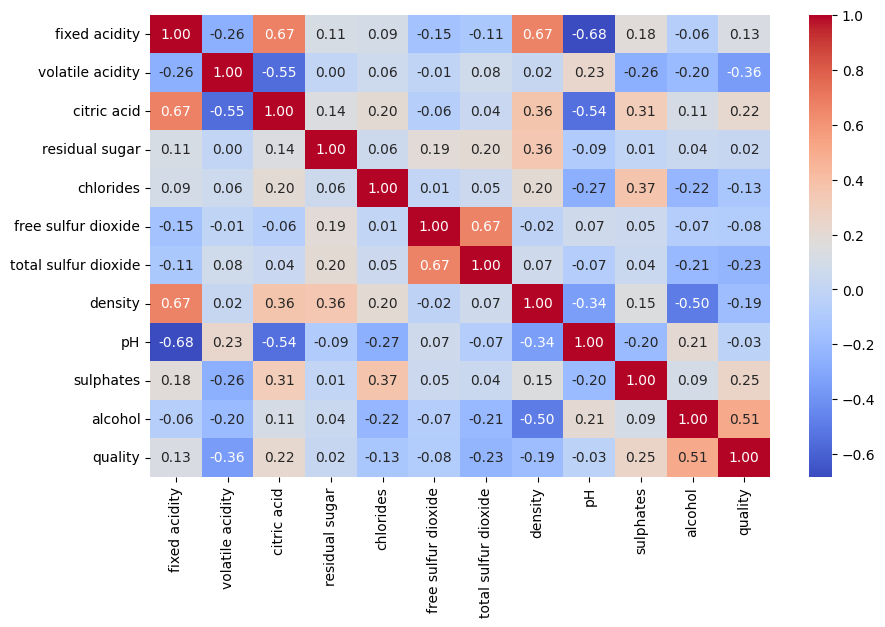

In [21]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [45]:
#lista de correlaciones entre cada variable y la variable objetivo
correlations = df.corr()["quality"].sort_values(ascending=False)
print(correlations)

quality                 1.000000
alcohol                 0.507839
sulphates               0.252378
citric acid             0.217913
fixed acidity           0.126195
residual sugar          0.021784
pH                     -0.030279
free sulfur dioxide    -0.078917
chlorides              -0.125326
density                -0.186537
total sulfur dioxide   -0.232983
volatile acidity       -0.360621
Name: quality, dtype: float64


**Interpretando las correlaciones**

    -Alcohol es la variable más influyente: Más alcohol aparentemente más calidad
    -Sulfitos y ácido cítrico como variables relevantes
    -Acidez volátil, sulfur dioxide total y densidad como las varibles con mayor correlación negativa

In [46]:
#correlaciones positivas entre cada par de variables
correlations_positive = df.corr().unstack().sort_values(ascending=False).drop_duplicates().head(10)
print(correlations_positive) 

fixed acidity         fixed acidity          1.000000
                      citric acid            0.671703
density               fixed acidity          0.668047
total sulfur dioxide  free sulfur dioxide    0.667666
alcohol               quality                0.507839
chlorides             sulphates              0.371260
density               citric acid            0.364947
residual sugar        density                0.355283
sulphates             citric acid            0.312770
                      quality                0.252378
dtype: float64


In [47]:
#correlaciones negativas entre cada par de variables
correlations_positive = df.corr().unstack().sort_values(ascending=True).drop_duplicates().head(10)
print(correlations_positive) 

fixed acidity     pH                     -0.682978
citric acid       volatile acidity       -0.552496
pH                citric acid            -0.541904
alcohol           density                -0.496180
volatile acidity  quality                -0.360621
density           pH                     -0.341699
chlorides         pH                     -0.265026
volatile acidity  sulphates              -0.260987
                  fixed acidity          -0.256131
quality           total sulfur dioxide   -0.232983
dtype: float64


**Multicolinealidad**

Variables con información redudante:

        -fixed acidity y citric acid (0.67)
        -density y fixed acidity (0.66)
        -free SO2 y total SO2 (0.66)


### 2. Entrena el modelo KNN.

    -Separa las variables independientes (X) del objetivo (y).

    -Divide en conjunto de entrenamiento y prueba (80/20).

    -Escala los datos si es necesario (¡muy recomendable con KNN!).

    -Entrena el modelo con un valor de k inicial.

In [ ]:
X = df.drop("quality", axis=1)
y = df["quality"]

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [52]:
print(f"X_train scaled shape: {X_train_scaled.shape}, X_test scaled shape: {X_test_scaled.shape}" )

X_train scaled shape: (1279, 11), X_test scaled shape: (320, 11)


In [58]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### 3. Evalúa el rendimiento usando:

    -accuracy_score

    -confusion_matrix

    -classification_report

In [59]:
y_pred = knn.predict(X_test_scaled)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.67      0.65       141
           1       0.53      0.55      0.54       132
           2       0.65      0.43      0.51        47

    accuracy                           0.58       320
   macro avg       0.60      0.55      0.57       320
weighted avg       0.59      0.58      0.58       320

Confusion Matrix:
[[95 45  1]
 [50 72 10]
 [ 7 20 20]]
Accuracy Score: 0.584375


**Primeras conclusiones**

    -Accuracy de 0.58. Por ahora muy baja pero considerando que la k es de 5 (con bastante margen de mejora)

    -**Clase 0** : El modelo identifica correctamente el 67% de los vinos de baja calidad; sin embargo en la predicción de vinos de baja calidad el rendimiento baja a 62%. 

    -**Clase 1** : El modelo identifica correctamente el 55% de los vinos de calidad media; sin embargo en la predicción de vinos de calidad media el rendimiento baja a 53%.

    -**Clase 2** : El modelo identifica correctamente el 43% de los vinos de alta calidad; sin embargo en la predicción de vinos de alta calidad el rendimiento sube a 65%.

### 4. Optimización de k. 
Crea un bucle para probar diferentes valores de k (por ejemplo, de 1 a 20).


    -Guarda los resultados en una lista.

    -Grafica accuracy vs k para encontrar el mejor valor.